In [1]:
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset, DataLoader

from config import *

In [2]:
test_df = pd.read_csv(TEST_CSV)
test_df.head()

,text,sentiment
0,Its WoW! effect Thanks for the update.,1
1,In a really Good mood for absolutely no reason...,1
2,"Loves the 2nd half of even days, orch and jazz...",1
3,last week and I interviewed and we told him...,1
4,Studio Ghibli for this year; Ponyo! as always...,1


In [3]:
test_reviews = test_df["text"]
test_labels = test_df["sentiment"]

In [5]:
import pickle
from src.Dataset import MyDataset

with open(VECTORIZER_PATH, "rb") as f:
    vectorizer = pickle.load(f)

X_test = vectorizer.transform(test_reviews)

test_set = MyDataset(
    X_test,
    test_labels
)

In [6]:

from src.Net import Net

net = Net()
net.load_state_dict(
    torch.load(MODEL_PATH)
)

<All keys matched successfully>

In [9]:
X_test = X_test.toarray()

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

Accuracy: 65.40%


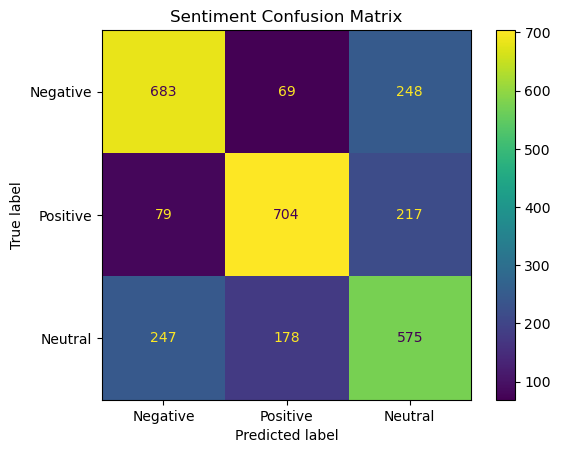

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

net.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for i in range(len(X_test_tensor)):

        review = X_test_tensor[i].unsqueeze(0)

        output = net(review)

        prediction = torch.argmax(output, dim=1)

        all_predictions.append(prediction.item())
        all_labels.append(test_labels[i])


accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy: {accuracy * 100:.2f}%")


cm = confusion_matrix(
    all_labels,
    all_predictions
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive",
        "Neutral"
    ]
)

disp.plot()

plt.title("Sentiment Confusion Matrix")
plt.show()

In [12]:
from config import MODEL_NAME

with open(f"./logs/[{MODEL_NAME}]_log.txt", "a") as f:    
    f.write(f"""\n\n
====================
Testing
====================

Accuracy: {accuracy * 100:.2f}%\n
Confusion Matrix:\n{cm}\n

""")

print("Accuracy added to experiment file")

Accuracy added to experiment file
